# Data exploration - loading images

Quick look at the dataset: load a few images via `load_image` and
confirm shapes, dtype and correct RGB colors.

In [20]:
import sys
sys.path.insert(0, "..")

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt

from src.data.loading import load_image
from src.data.inventory import find_images

In [22]:
DATA_DIR = Path("../data")
paths = find_images(DATA_DIR)
print(f"Found {len(paths)} images")
samples = paths[:6]

Found 6 images


## Inspect a single image

shape: (1080, 1920, 3) dtype: uint8
min: 0 max: 255


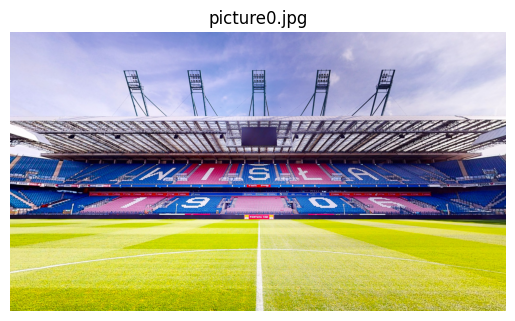

In [23]:
img = load_image(samples[0])
print("shape:", img.shape, "dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())

plt.imshow(img)
plt.axis("off")
plt.title(samples[0].name);

## A few samples

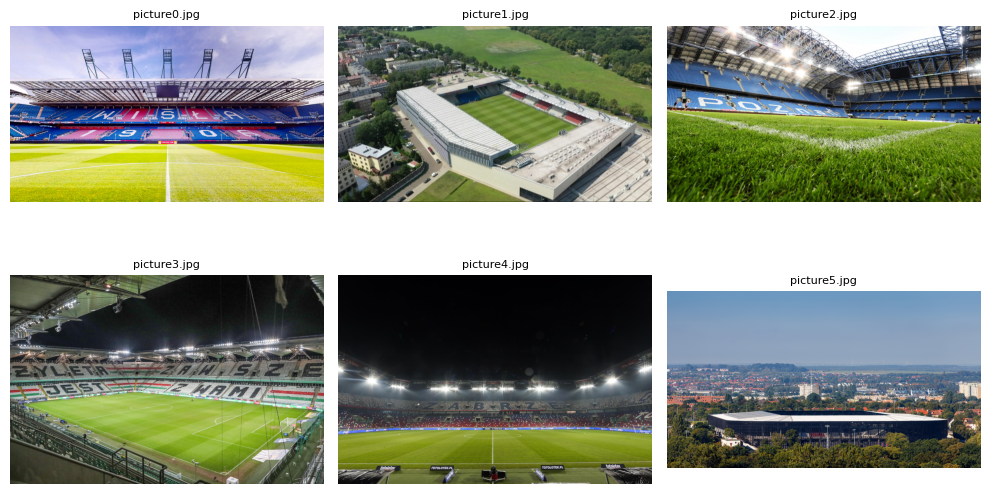

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, p in zip(axes.ravel(), samples):
    ax.imshow(load_image(p))
    ax.set_title(p.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()

## Why the BGR -> RGB conversion matters

OpenCV loads images as BGR. Displaying that array directly swaps red
and blue. `load_image` fixes this.

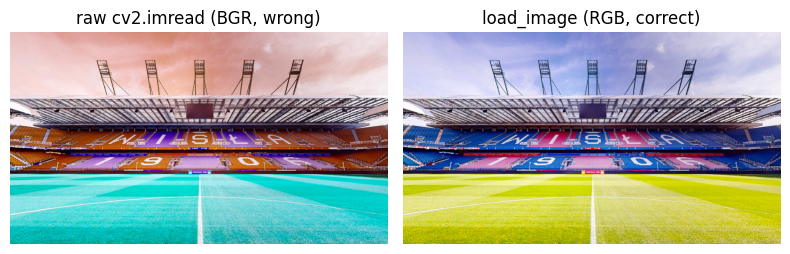

In [25]:
import cv2

raw_bgr = cv2.imread(str(samples[0]), cv2.IMREAD_COLOR)
fixed_rgb = load_image(samples[0])

fig, (a, b) = plt.subplots(1, 2, figsize=(8, 4))
a.imshow(raw_bgr);  a.set_title("raw cv2.imread (BGR, wrong)");  a.axis("off")
b.imshow(fixed_rgb); b.set_title("load_image (RGB, correct)"); b.axis("off")
plt.tight_layout()

## Mask overlay (synthetic mask)

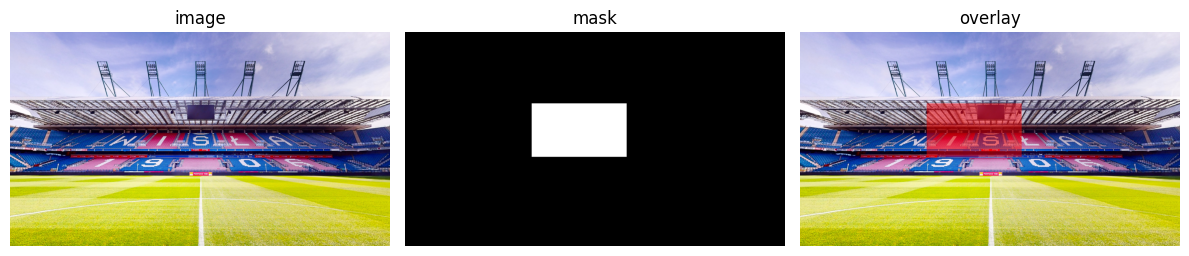

In [26]:
import numpy as np
from src.data.mask import overlay_mask

mask = np.zeros(img.shape[:2], dtype=np.uint8)
h, w = img.shape[:2]
y0, x0 = h // 3, w // 3
mask[y0:y0 + h // 4, x0:x0 + w // 4] = 255

over = overlay_mask(img, mask)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title("image"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("mask"); axes[1].axis("off")
axes[2].imshow(over)
axes[2].set_title("overlay"); axes[2].axis("off")
plt.tight_layout()